In [1]:
# Plot population time series

In [2]:
import xarray as xr
import regionmask
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
# === Figure sizing ===
def autosize_figure(nrows, ncolumns, scale_factor=1, xscale_factor=1, yscale_factor=1):
    xwidth = (ncolumns+0.67) * 5.0 * scale_factor * xscale_factor
    ylength = (nrows+0.67) * 3.6 * scale_factor * yscale_factor
    return (xwidth, ylength)


# === Removing ocean ===
def land_filter(da):
    # Load in land fraction dataset
    land_110 = regionmask.defined_regions.natural_earth_v4_1_0.land_110
    da = da.where(land_110.mask_3D(da).squeeze())
    return da


# === Latitude weighting sum ===
def weighted_sum(da):
    weights = np.cos(np.deg2rad(da.lat))
    weights.name = "weights"
    new_da = da.weighted(weights).sum(("lon", "lat"))
    return new_da

In [4]:
# === Path config ===
POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"

pop_ssp2 = xr.open_dataarray(f"{POP_DIR}ssp2_total_regrid_2000-2100.nc")

In [7]:
pop_timeseries = weighted_sum(pop_ssp2)

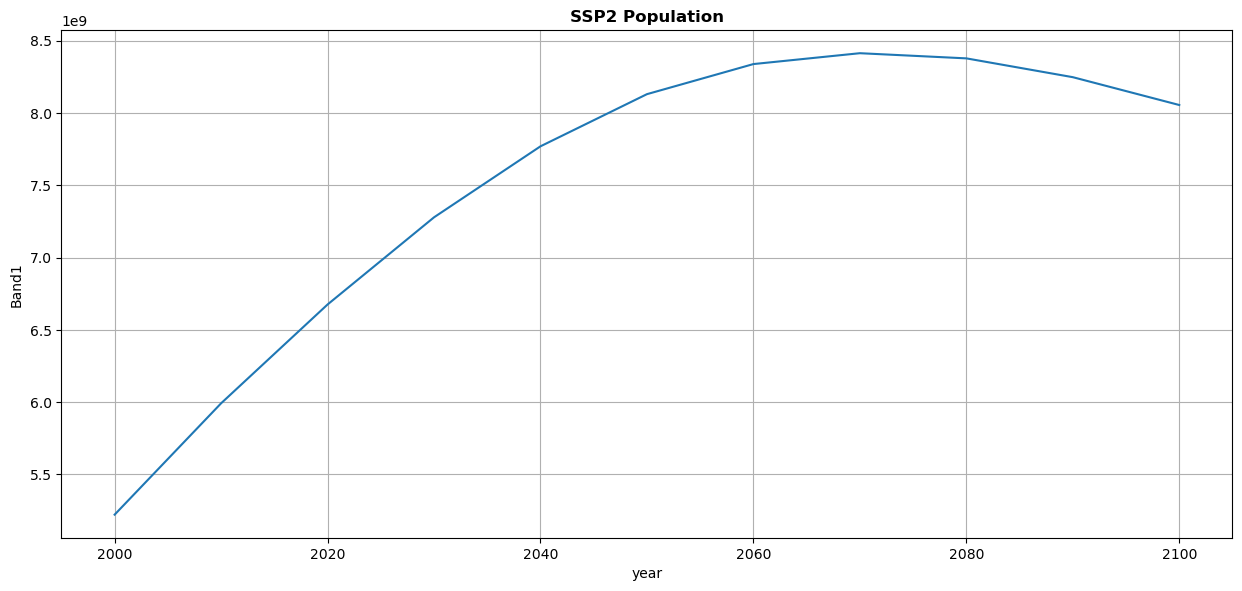

In [8]:
fig = plt.figure(figsize=autosize_figure(1, 1, xscale_factor=1.5))
gs = GridSpec(1, 1) # rows, columns

# First panel
ax = fig.add_subplot(gs[0, 0], frameon=True)
cb = pop_timeseries.plot()
plt.grid()
plt.title("SSP2 Population", fontweight='bold')

plt.tight_layout()